# EDA Import and setup

In [21]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from tqdm import tqdm
from scipy.signal import welch

# Prepare Data for EDA

In [22]:
csv_frdr = r"dataset\urban-frdr\inspections_2022.csv"
csv_zenodo = r"dataset\zenodo\state_labels.csv"
frdr_audiofolder_path = r"dataset/urban-frdr/audio_2022_all_chunk"
zenodo_audiofolder_path = r"dataset\zenodo"

In [23]:
df_frdr = pd.read_csv(csv_frdr)
df_frdr = df_frdr[(df_frdr['Queen status'] == 'queenless') | (df_frdr['Category'] == 'varroa')]


In [24]:
extract_list = []
for file_name in os.listdir(frdr_audiofolder_path):
    if not file_name.endswith('.wav'):
        continue
    parts = file_name.split('_')
    date = pd.to_datetime(parts[0], format='%d-%m-%Y').strftime('%Y-%m-%d')
    hive_id = parts[2].split('-')[1].split('.')[0]
    extract_list.append({'Filename': file_name, 'Date': date, 'Tag number': int(hive_id)})

df_audio = pd.DataFrame(extract_list)
df_frdr['Tag number'] = df_frdr['Tag number'].astype(int)
df_frdr['Date'] = pd.to_datetime(df_frdr['Date']).dt.strftime('%Y-%m-%d')
df_frdr = df_frdr.sort_values(['Date', 'Tag number', 'Category']).drop_duplicates(['Date', 'Tag number'], keep='first')
merge_df = pd.merge(df_audio, df_frdr, on=['Date', 'Tag number'], how='inner')

def get_class(row):
    if row['Category'] == 'varroa':
        return 'Class 2: Infested'
    if row['Queen status'] == 'queenless':
        return 'Class 1: Queenless'
    if row['Queen status'] == 'queenright' and row['Is alive'] == 1:
        return 'Class 0: Active'
    return 'Others / Ignored'

merge_df['target_Class'] = merge_df.apply(get_class, axis=1)
print(merge_df['target_Class'].value_counts())


target_Class
Class 2: Infested     162
Class 1: Queenless     83
Name: count, dtype: int64


In [25]:
frdr_data = []
for path in glob.glob(os.path.join(frdr_audiofolder_path, '*.wav')):
    name = os.path.basename(path)
    if 'Active' in name or 'Queenless' in name or 'Infested' in name:
        cls = name.split('_')[-1].split('.')[0]
        hive = 'Unknown'
        for p in name.split('_'):
            if 'HIVE' in p:
                hive = p
                break
        frdr_data.append({'File_Path': path, 'Filename': name, 'Dataset': 'FRDR', 'Class': cls, 'Hive': hive})
df_frdr_all = pd.DataFrame(frdr_data)

zenodo_data = []
for path in glob.glob(os.path.join(zenodo_audiofolder_path, '*', '*.wav')):
    name = os.path.basename(path)
    folder = os.path.basename(os.path.dirname(path))
    if 'NO_QueenBee' in name:
        cls = 'Queenless'
    elif 'QueenBee' in name:
        cls = 'Active'
    else:
        continue
    zenodo_data.append({'File_Path': path, 'Filename': name, 'Dataset': 'ZENODO', 'Class': cls, 'Hive': folder.split('_')[0]})
df_zenodo_all = pd.DataFrame(zenodo_data)

print(f"FRDR: {len(df_frdr_all)} files | Zenodo: {len(df_zenodo_all)} files")


FRDR: 393 files | Zenodo: 576 files


In [26]:
sr = 16000
duration = 10

all_audio_files = glob.glob(r"dataset\**\*.wav", recursive=True)
duration_data = []
for path in all_audio_files:
    name = os.path.basename(path).lower()
    if any(s in name for s in ['_active', '_queenless', '_infested']):
        dataset = 'URBAN-FRDR'
    elif 'queenbee' in name or 'no_queenbee' in name:
        dataset = 'ZENODO'
    else:
        continue
    try:
        dur = librosa.get_duration(path=path)
        duration_data.append({'Dataset': dataset, 'Duration': dur})
    except:
        pass

df_durations = pd.DataFrame(duration_data)


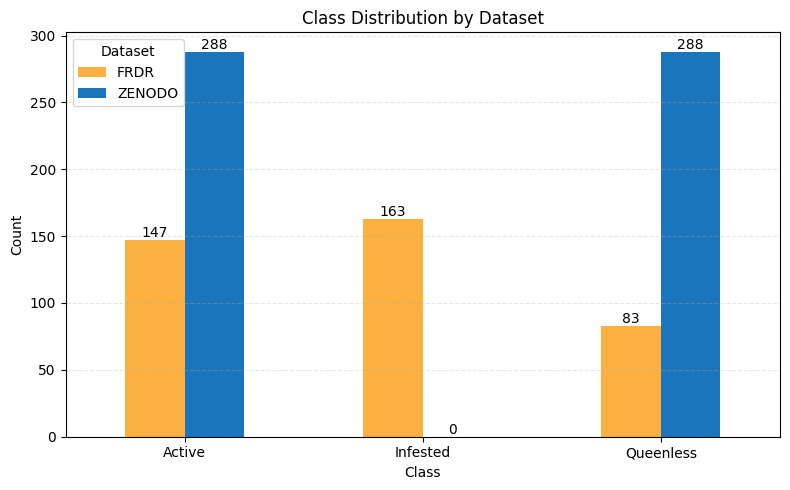

In [27]:
df_all = pd.concat([df_frdr_all, df_zenodo_all], ignore_index=True)

ct = pd.crosstab(df_all['Class'], df_all['Dataset'])
ax = ct.plot(kind='bar', figsize=(8, 5), rot=0, color=['#fbb040', '#1b75bc'], linewidth=0.5)
plt.title('Class Distribution by Dataset')
plt.ylabel('Count')
plt.legend(title='Dataset')
for container in ax.containers:
    ax.bar_label(container)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()


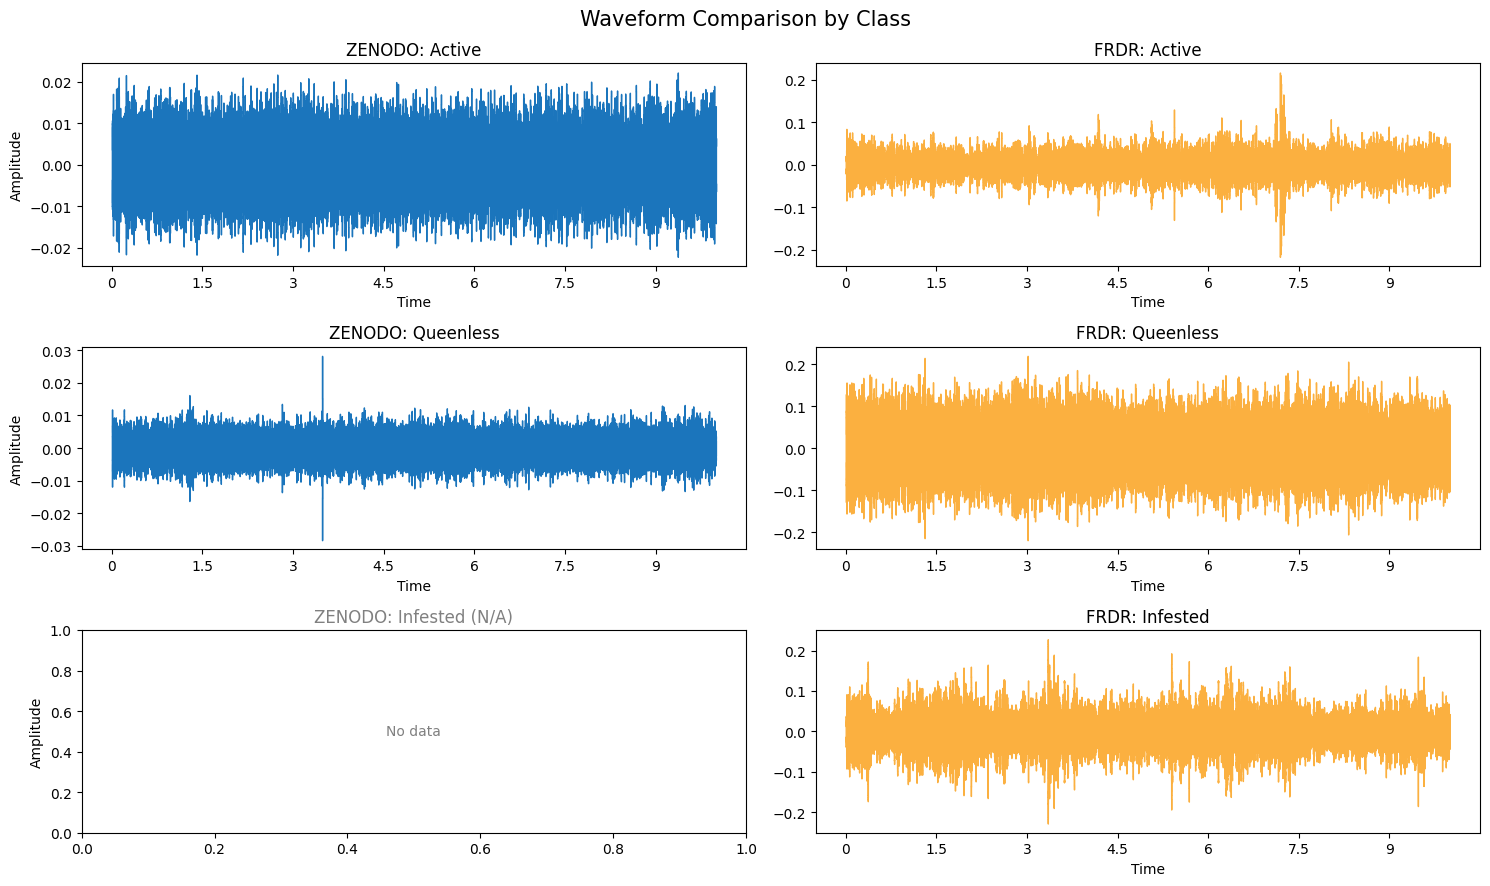

In [28]:
sr = 16000
duration = 10

paths = {}
for ds_name, ds_df in [('FRDR', df_frdr_all), ('ZENODO', df_zenodo_all)]:
    for cls in ds_df['Class'].unique():
        paths[f'{ds_name}_{cls}'] = ds_df[ds_df['Class'] == cls].iloc[0]['File_Path']

audio = {k: librosa.load(v, sr=sr, duration=duration)[0] for k, v in paths.items()}

classes = ['Active', 'Queenless', 'Infested']
datasets = ['ZENODO', 'FRDR']
fig, axes = plt.subplots(3, 2, figsize=(15, 9))
fig.suptitle('Waveform Comparison by Class', fontsize=15)

for i, cls in enumerate(classes):
    for j, ds in enumerate(datasets):
        key = f'{ds}_{cls}'
        ax = axes[i, j]
        if key in audio:
            color = '#1b75bc' if ds == 'ZENODO' else '#fbb040'
            librosa.display.waveshow(audio[key], sr=sr, ax=ax, color=color)
            ax.set_title(f'{ds}: {cls}')
        else:
            ax.set_title(f'{ds}: {cls} (N/A)', color='gray')
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, color='gray')
        if j == 0:
            ax.set_ylabel('Amplitude')

plt.tight_layout(); plt.show()


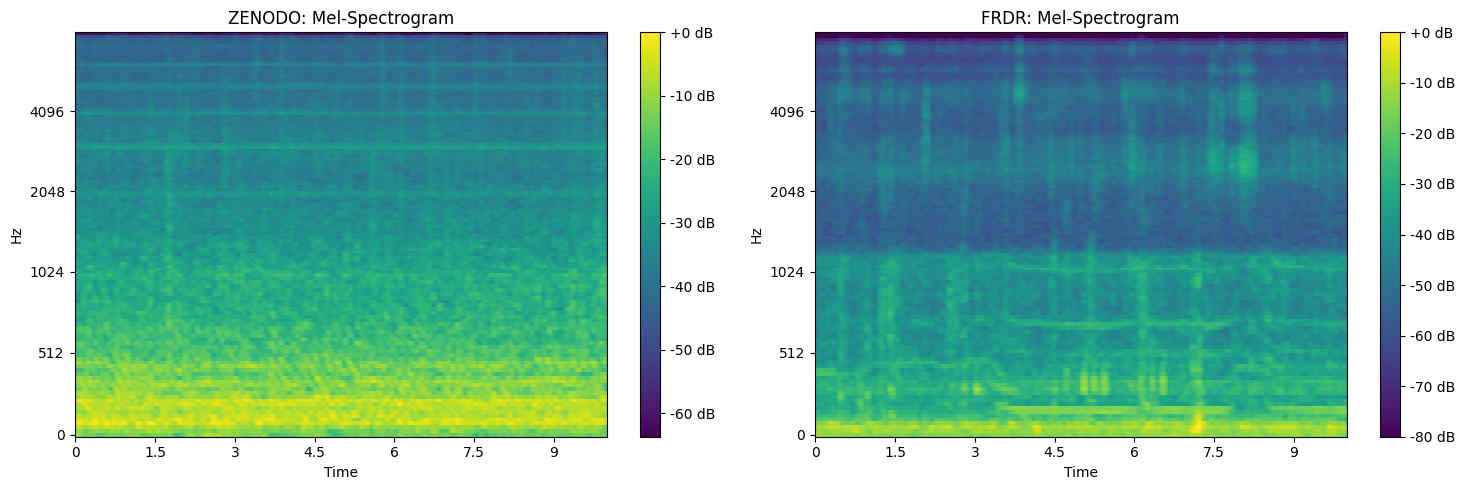

In [29]:
# Uses audio dict from waveform cell. Run eda_waveform first or load manually.
try:
    audio
except NameError:
    print('Run eda_waveform cell first to load audio')
    raise

n_fft = 4096
hop_length = 512

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (ds, color) in enumerate([('ZENODO', '#1b75bc'), ('FRDR', '#fbb040')]):
    key = f'{ds}_Active'
    y = audio[key] / (np.max(np.abs(audio[key])) + 1e-10)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    axes[idx].set_title(f'{ds}: Mel-Spectrogram')
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[idx], cmap='viridis')
    fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')

plt.tight_layout(); plt.show()


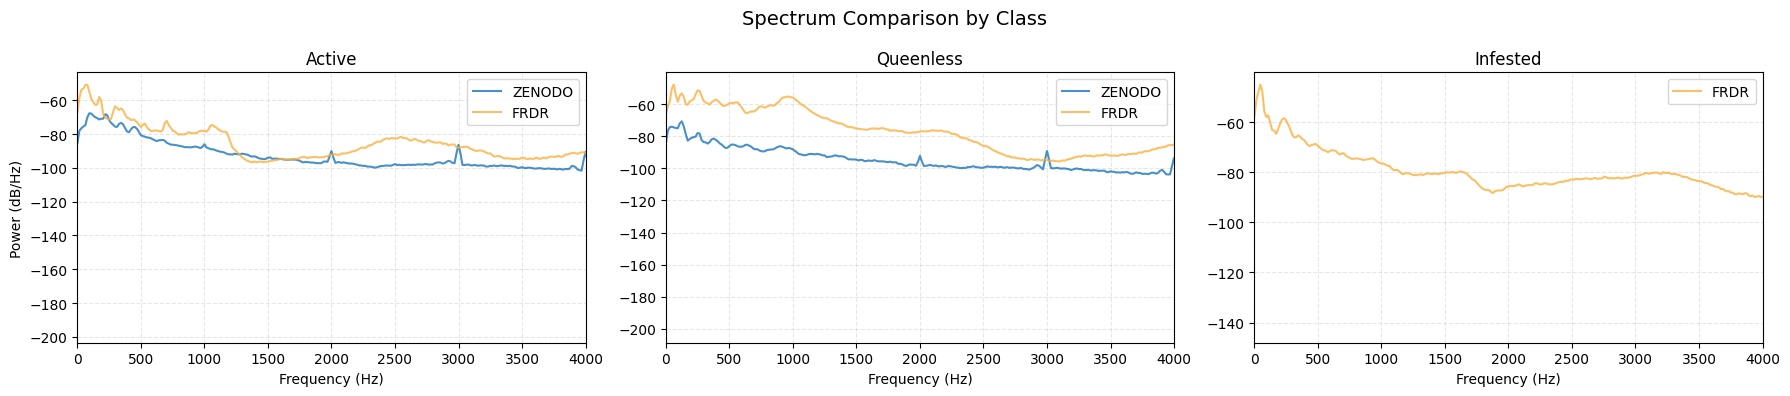

In [30]:
sr = 16000
duration = 10

try:
    audio
except NameError:
    audio = {}
    for ds_name, ds_df in [('FRDR', df_frdr_all), ('ZENODO', df_zenodo_all)]:
        for cls in ds_df['Class'].unique():
            path = ds_df[ds_df['Class'] == cls].iloc[0]['File_Path']
            audio[f'{ds_name}_{cls}'] = librosa.load(path, sr=sr, duration=duration)[0]

classes = ['Active', 'Queenless', 'Infested']
datasets = ['ZENODO', 'FRDR']
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Spectrum Comparison by Class', fontsize=14)

for i, cls in enumerate(classes):
    for ds in datasets:
        key = f'{ds}_{cls}'
        if key in audio:
            freqs, psd = welch(audio[key], sr, nperseg=1024)
            color = '#1b75bc' if ds == 'ZENODO' else '#fbb040'
            axes[i].plot(freqs, 10 * np.log10(psd), color=color, label=f'{ds}', alpha=0.8)
    axes[i].set_title(cls)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_xlim(0, 4000)
    axes[i].grid(True, linestyle='--', alpha=0.3)
    axes[i].legend()

axes[0].set_ylabel('Power (dB/Hz)')
plt.tight_layout(); plt.show()


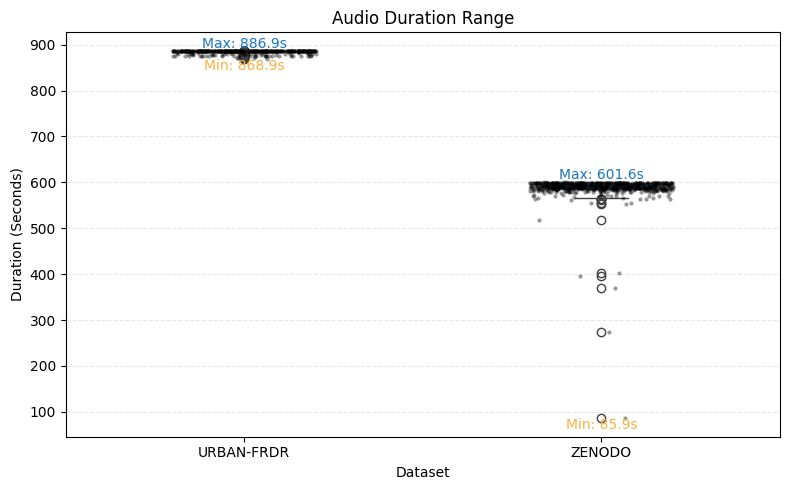

In [31]:
plt.figure(figsize=(8, 5))
palette = {'URBAN-FRDR': '#fbb040', 'ZENODO': '#1b75bc'}
sns.boxplot(data=df_durations, x='Dataset', y='Duration', palette=palette, width=0.3, hue='Dataset', legend=False)
sns.stripplot(data=df_durations, x='Dataset', y='Duration', color='black', size=3, alpha=0.4, jitter=0.2)

for i, dn in enumerate(['URBAN-FRDR', 'ZENODO']):
    sub = df_durations[df_durations['Dataset'] == dn]['Duration']
    if len(sub) > 0:
        plt.text(i, sub.max(), f"Max: {sub.max():.1f}s", ha='center', va='bottom', color='#1b75bc', fontsize=10)
        plt.text(i, sub.min(), f"Min: {sub.min():.1f}s", ha='center', va='top', color='#fbb040', fontsize=10)

plt.title('Audio Duration Range')
plt.xlabel('Dataset')
plt.ylabel('Duration (Seconds)')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()


In [32]:
too_short = df_durations[(df_durations['Dataset'] == 'ZENODO') & (df_durations['Duration'] < 500)]

if len(too_short) == 0:
    print('Not found')
else:
    print(f'Too short found: {len(too_short)} File\n')
    for _, row in too_short.iterrows():
        target = row['Duration']
        found = None
        for path in all_audio_files:
            if 'queenbee' in path.lower() or 'no_queenbee' in path.lower():
                try:
                    if abs(librosa.get_duration(path=path) - target) < 0.1:
                        found = os.path.basename(path)
                        break
                except:
                    pass
        print(f'File: {found}')
        print(f'Duration: {target:.2f}s ({target/60:.1f} min)\n')


Too short found: 5 File

File: Hive3_14_07_2017_NO_QueenBee____07_30_00.wav
Duration: 274.00s (4.6 min)

File: Hive3_14_07_2017_NO_QueenBee____09_30_00.wav
Duration: 397.06s (6.6 min)

File: Hive3_28_07_2017_QueenBee____07_40_00.wav
Duration: 369.20s (6.2 min)

File: Hive3_28_07_2017_QueenBee____11_30_00.wav
Duration: 402.52s (6.7 min)

File: Hive3_28_07_2017_QueenBee____12_40_00.wav
Duration: 85.91s (1.4 min)



Extracting features: 100%|██████████| 969/969 [00:29<00:00, 32.85it/s]


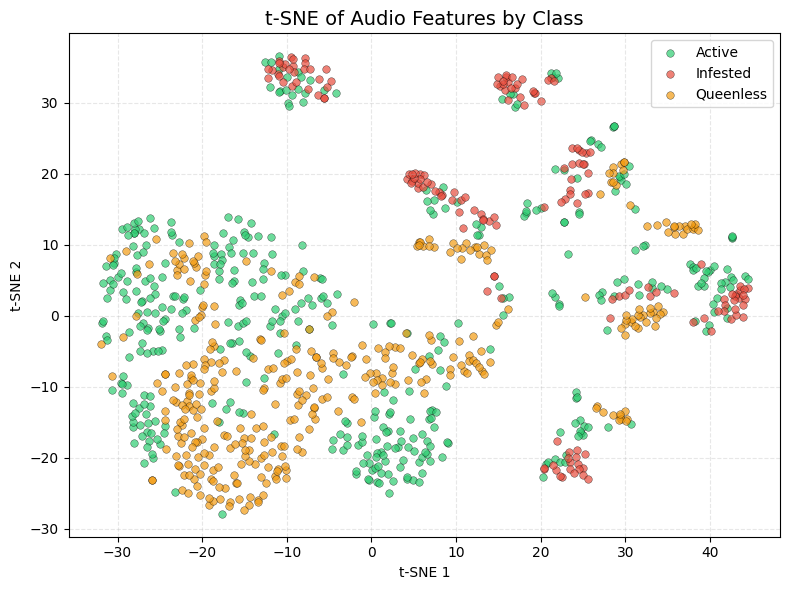

Extracted features from 969 files


In [33]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

df_all = pd.concat([df_frdr_all, df_zenodo_all], ignore_index=True)

feature_list, labels = [], []

for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc='Extracting features'):
    try:
        y, _ = librosa.load(row['File_Path'], sr=16000, duration=10)
        if len(y) == 0:
            continue
        mfcc = librosa.feature.mfcc(y=y, sr=16000, n_mfcc=13)
        mfcc_feat = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])
        cent = librosa.feature.spectral_centroid(y=y, sr=16000)[0]
        roll = librosa.feature.spectral_rolloff(y=y, sr=16000)[0]
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        rms = librosa.feature.rms(y=y)[0]
        feat = np.concatenate([mfcc_feat, [cent.mean(), cent.std(), roll.mean(), roll.std(), zcr.mean(), zcr.std(), rms.mean(), rms.std()]])
        feature_list.append(feat)
        labels.append(row['Class'])
    except Exception as e:
        print(f'Skip {row["Filename"]}: {e}')

X = StandardScaler().fit_transform(np.array(feature_list))
y = np.array(labels)

X_tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X) - 1)).fit_transform(X)

colors = {'Active': '#2ECC71', 'Queenless': '#F39C12', 'Infested': '#E74C3C'}
plt.figure(figsize=(8, 6))
for cls in np.unique(y):
    mask = y == cls
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[cls], label=cls, alpha=0.7, edgecolors='black', linewidth=0.3, s=30)
plt.title('t-SNE of Audio Features by Class', fontsize=14)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Extracted features from {len(X)} files')
